In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re
from copy import deepcopy
import glob
from pathlib import Path
from collections import defaultdict
import itertools
from scipy.interpolate import interp1d

import sys
sys.path.append('/homes/dfs1/Refltools')

from RSoXRReduction import RSoXRProcessor  # Import your RSoXRProcessor class

# Setup Directories for data reduction

In [2]:
DATA_DIR = "/homes/dfs1/Reflectivity/Data_Reduction/UV Stack/Carbon"
LOG_FILE = "/homes/dfs1/Reflectivity/Data_Reduction/May2025.log" #\\resdata-smb.nist.gov\saxs8542\EUV_Resist_Project\ALS 632 Data\May 2025
CALIB_FILE = "/home2/dfs1/Reflectivity/632Data/Data Reduction/632PhotodiodeCalibration.xlsx"
OUTPUT_DIR = "/homes/dfs1/Reflectivity/Data_Reduction/UV Stack/Carbon"
OPEN_BEAM = "/homes/dfs1/Reflectivity/Data_Reduction/Open_Beam_C000000.dat"

# Initialize Processor with logfile and calibrationfile

In [3]:
processor = RSoXRProcessor(LOG_FILE, CALIB_FILE)

Could not load calibration file /home2/dfs1/Reflectivity/632Data/Data Reduction/632PhotodiodeCalibration.xlsx, creating default calibration data


/homes/dfs1/Refltools/RSoXRReduction.py:57: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.calibration_data = pd.read_csv(calibration_file,


Loading open beam file: /homes/dfs1/Reflectivity/Data_Reduction/Open_Beam_C000000.dat
Loaded data shape: (301, 4)
Using columns: Energy (col 1), Intensity (col 2)
Also loaded error column (col 3)
Also loaded monitor/additional data (col 4)
Successfully loaded open beam data from Open_Beam_C000000.dat
Energy range: 250.0 - 350.0 eV
Data points: 301
Sample data:
  First few points: Energy=250.0 eV, Intensity=2.921e+00
  Last few points: Energy=350.0 eV, Intensity=7.977e+00


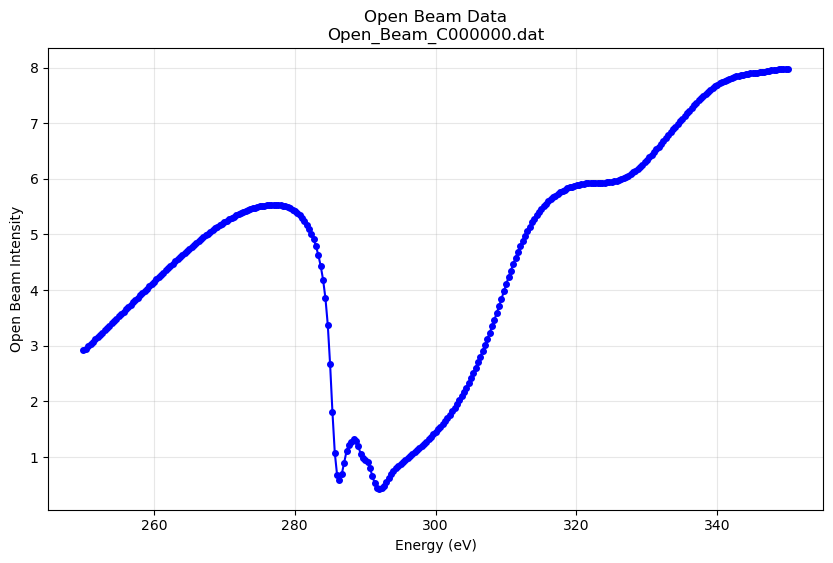

In [4]:
success = processor.load_open_beam_file(OPEN_BEAM)
processor.plot_open_beam_data()

In [5]:
groups = processor.auto_group_scans(
        data_directory=DATA_DIR,
        position_tolerance=0.6,
        energy_tolerance=0.2,
        auto_trim=True,
        save_table=True,
        output_dir=OUTPUT_DIR
    )

Found 55 potential raw data files

Found 30 scan groups:
#   | Sample       | Energy (eV) | Position (X,Y)       | Angle Range     | Files    | Detector Types
-------------------------------------------------------------------------------------------------------------------
  1 | UVStack      |      270.0 | (21.00, 5.01)        | 0.00 - 1.00°    |        2 | cem digital (2)
  2 | UVStack      |      270.0 | (21.50, 5.01)        | -0.00 - 0.88°   |        1 | photodiode (1)
  3 | UVStack      |      280.0 | (19.50, 5.02)        | 0.00 - 31.86°   |        3 | photodiode (1), cem digital (2)
  4 | UVStack      |      280.0 | (19.50, 5.02)        | 29.00 - 45.00°  |        1 | cem digital (1)
  5 | UVStack      |      282.0 | (19.50, 5.01)        | 0.00 - 12.00°   |        1 | photodiode (1)
  6 | UVStack      |      284.0 | (19.50, 5.01)        | 0.00 - 45.00°   |        4 | photodiode (1), cem digital (3)
  7 | UVStack      |      284.5 | (19.75, 5.01)        | 0.00 - 12.00°   |        1

In [6]:
groups = processor.edit_groups(scan_groups=groups, group=1, add_scan_number=4)
processor.print_groups_with_scan_numbers(groups, show_details=True)

Moved scans [4] to group 1

Scan Groups Summary (30 groups):

Group 1: UVStack (270.0 eV)
Position: (21.00, 5.01)
Files: 3
Scan#  | Filename                  | Detector     | Angle Range    
-----------------------------------------------------------------
     1 | UVStack_C_PD000000.dat    | photodiode   | 0.00-12.00°    
     2 | UVStack_C_CT1000010.dat   | cem digital  | 0.00-1.00°     
     4 | UVStack_C_CT2000010.dat   | cem digital  | 0.00-1.00°     


Group 2: UVStack (270.0 eV)
Position: (21.50, 5.01)
Files: 1
Scan#  | Filename                  | Detector     | Angle Range    
-----------------------------------------------------------------
     3 | UVStack_C_PD000026.dat    | photodiode   | -0.00-0.88°    


Group 3: UVStack (280.0 eV)
Position: (19.50, 5.02)
Files: 2
Scan#  | Filename                  | Detector     | Angle Range    
-----------------------------------------------------------------
     5 | UVStack_C_CT1000000.dat   | cem digital  | 10.00-20.00°   
     6 | 

In [ ]:
from RSoXRWidgets import RSoXRTrimWidget
trim_widget = RSoXRTrimWidget(processor,scan_groups=groups, data_directory=DATA_DIR, default_output_dir=OUTPUT_DIR, open_beam=OPEN_BEAM )
trim_widget.display()

Example usage:
viewer = create_reflectivity_viewer(data_dir='data', file_prefix='Prefix_')
# Or with default parameters (current directory, no specific prefix):
viewer = create_reflectivity_viewer()
Example usage:
viewer = create_multi_curve_viewer(data_dir='data', file_prefix='Prefix_')
# Or with default parameters (current directory, no specific prefix):
viewer = create_multi_curve_viewer()


Auto-generating stitching preview...


Loading open beam data from initialization parameter: /homes/dfs1/Reflectivity/Data_Reduction/Open_Beam_C000000.dat
Loading open beam file: /homes/dfs1/Reflectivity/Data_Reduction/Open_Beam_C000000.dat
Loaded data shape: (301, 4)
Using columns: Energy (col 1), Intensity (col 2)
Also loaded error column (col 3)
Also loaded monitor/additional data (col 4)
Successfully loaded open beam data from Open_Beam_C000000.dat
Energy range: 250.0 - 350.0 eV
Data points: 301
Sample data:
  First few points: Energy=250.0 eV, Intensity=2.921e+00
  Last few points: Energy=350.0 eV, Intensity=7.977e+00
Normalization set to: open beam
✓ Open beam data loaded and enabled successfully!
  Energy range: 250.0 - 350.0 eV
  Data points: 301
  Open beam normalization: ENABLED


RSoXR Trim Widget initialized with default output directory: /homes/dfs1/Reflectivity/Data_Reduction/UV Stack/Carbon
Default trim values set to use full range of each data section (0, -1)
Loaded 30 scan groups with scan numbering
Scan numbering: 55 total scans (#1 to #55)


Auto-generating stitching preview...
